aircraft_detection_pipeline.svg

In [ ]:
# Cell 1: Install dependencies & Mount Google Drive
!pip install -q ultralytics torchmetrics torchvision opencv-python tqdm

from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

# Verify dataset exists
if not os.path.exists('/content/drive/MyDrive/mil-plane'):
    print("⚠️ Dataset not found! Please ensure your folder is named 'mil-plane' and sits at the root of your MyDrive.")
else:
    print("✅ Dataset found successfully in Google Drive!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 37.5 MB/s eta 0:00:00
Mounted at /content/drive
✅ Dataset found successfully in Google Drive!


In [ ]:
# Cell 2: Central Configuration (T4 GPU Optimized for Colab)
# config.py
import os
import torch

# Dataset paths
BASE_DIR   = "/content/drive/MyDrive/mil-plane"
JPEG_DIR   = os.path.join(BASE_DIR, "JPEGImages")
HORIZ_XML  = os.path.join(BASE_DIR, "Annotations", "Horizontal Bounding Boxes")
OBB_XML    = os.path.join(BASE_DIR, "Annotations", "Oriented Bounding Boxes")
SPLIT_DIR  = os.path.join(BASE_DIR, "ImageSets", "Main")

# Output paths for YOLO-formatted data
OUT_DIR         = "/content/yolo_dataset"
HORIZ_YAML      = os.path.join(OUT_DIR, "horiz", "data.yaml")
OBB_YAML        = os.path.join(OUT_DIR, "obb", "data.yaml")

# ──────────────────────────────────────────────
# GLOBAL TRAINING SETTINGS (2026 Speed Run)
# ──────────────────────────────────────────────
DEVICE       = "0" if torch.cuda.is_available() else "cpu"
WORKERS      = 2
YOLO_EPOCHS  = 50
YOLO_BATCH   = 48       # Optimized for Tesla T4 (16GB)
YOLO_IMGSZ   = 640
YOLO_PATIENCE = 15

# Model Checkpoint Paths (Persistent Google Drive Backups)
# Use these for evaluate.py and app.py to avoid data loss on runtime restart
DRIVE_WEIGHTS = "/content/drive/MyDrive/mil-plane/weights_backup"

PATH_V11_H   = os.path.join(DRIVE_WEIGHTS, "yolo11h_best.pt")
PATH_V11_OBB = os.path.join(DRIVE_WEIGHTS, "yolo11obb_best.pt")
PATH_V26_N   = os.path.join(DRIVE_WEIGHTS, "yolo26_best.pt")

In [ ]:
# Cell 3: Prepare Dataset (OVERDRIVE Google Drive Optimized)
import json, shutil, os, concurrent.futures
import xml.etree.ElementTree as ET
from pathlib import Path
from PIL import Image
from tqdm.notebook import tqdm

def read_ids(filepath):
    return {line.strip() for line in Path(filepath).read_text().splitlines() if line.strip()}

def build_class_map(xml_dir):
    names = set()
    for xml_file in Path(xml_dir).glob("*.xml"):
        try:
            tree = ET.parse(xml_file)
            for obj in tree.findall("object"):
                name_el = obj.find("name")
                if name_el is not None and name_el.text: names.add(name_el.text.strip())
        except ET.ParseError: pass
    return {name: idx for idx, name in enumerate(sorted(names))}

def convert_horiz(xml_path, w, h, class_to_id):
    tree, lines = ET.parse(xml_path), []
    for obj in tree.findall("object"):
        name_el = obj.find("name")
        if name_el is None or name_el.text not in class_to_id: continue
        cls_id = class_to_id[name_el.text.strip()]
        bnd = obj.find("bndbox")
        if bnd is None: continue
        try:
            xmin, ymin = max(0, float(bnd.findtext("xmin", "0"))), max(0, float(bnd.findtext("ymin", "0")))
            xmax, ymax = min(w, float(bnd.findtext("xmax", "0"))), min(h, float(bnd.findtext("ymax", "0")))
        except ValueError: continue
        if xmax <= xmin or ymax <= ymin: continue
        xc, yc = (xmin + xmax) / (2 * w), (ymin + ymax) / (2 * h)
        bw, bh = (xmax - xmin) / w, (ymax - ymin) / h
        lines.append(f"{cls_id} {xc:.6f} {yc:.6f} {bw:.6f} {bh:.6f}")
    return lines

def convert_obb(xml_path, w, h, class_to_id):
    tree, lines = ET.parse(xml_path), []
    for obj in tree.findall("object"):
        name_el = obj.find("name")
        if name_el is None or name_el.text not in class_to_id: continue
        cls_id = class_to_id[name_el.text.strip()]
        rb = obj.find("robndbox")
        if rb is None: continue
        try:
            coords = [
                float(rb.findtext("x_left_top", "0")) / w, float(rb.findtext("y_left_top", "0")) / h,
                float(rb.findtext("x_right_top", "0")) / w, float(rb.findtext("y_right_top", "0")) / h,
                float(rb.findtext("x_right_bottom", "0")) / w, float(rb.findtext("y_right_bottom", "0")) / h,
                float(rb.findtext("x_left_bottom", "0")) / w, float(rb.findtext("y_left_bottom", "0")) / h,
            ]
        except ValueError: continue
        lines.append(f"{cls_id} " + " ".join(f"{c:.6f}" for c in coords))
    return lines

def process_image(task):
    img_file, img_id, split, class_to_id = task
    horiz_path = os.path.join(HORIZ_XML, img_id + ".xml")
    if not os.path.exists(horiz_path): return {"skipped": f"{img_id}: missing XML"}
    try: tree = ET.parse(horiz_path)
    except: return {"skipped": f"{img_id}: XML parse error"}

    root = tree.getroot()
    size = root.find("size")
    img_src = os.path.join(JPEG_DIR, img_file)

    w, h = 0, 0
    if size is not None:
        try:
            w = int(float(size.findtext("width", "0")))
            h = int(float(size.findtext("height", "0")))
        except ValueError: pass

    if w <= 0 or h <= 0:
        try:
            with Image.open(img_src) as pil_img: w, h = pil_img.size
        except: return {"skipped": f"{img_id}: corrupt image"}

    objects = root.findall("object")
    if not objects: return {"skipped": f"{img_id}: no objects"}

    h_lines = convert_horiz(horiz_path, w, h, class_to_id)
    if not h_lines: return {"skipped": f"{img_id}: no valid boxes"}

    horiz_dir = os.path.join(OUT_DIR, "horiz")
    h_img_dst = os.path.join(horiz_dir, "images", split, img_file)
    if not os.path.exists(h_img_dst):
        shutil.copyfile(img_src, h_img_dst)
    Path(os.path.join(horiz_dir, "labels", split, img_id + ".txt")).write_text("\n".join(h_lines))

    obb_path = os.path.join(OBB_XML, img_id + ".xml")
    if os.path.exists(obb_path):
        try: o_lines = convert_obb(obb_path, w, h, class_to_id)
        except: o_lines = []
        if o_lines:
            obb_dir = os.path.join(OUT_DIR, "obb")
            o_img_dst = os.path.join(obb_dir, "images", split, img_file)
            if not os.path.exists(o_img_dst):
                # If we already copied it for horiz, we can instantly copy it from the local disk instead of Drive!
                shutil.copyfile(h_img_dst, o_img_dst)
            Path(os.path.join(obb_dir, "labels", split, img_id + ".txt")).write_text("\n".join(o_lines))

    return {"split": split, "h_boxes": len(h_lines)}

# Setup dirs
for sub in ["horiz/images/train", "horiz/images/val", "horiz/labels/train", "horiz/labels/val",
            "obb/images/train", "obb/images/val", "obb/labels/train", "obb/labels/val"]:
    os.makedirs(os.path.join(OUT_DIR, sub), exist_ok=True)

class_to_id = build_class_map(HORIZ_XML)
train_ids = read_ids(os.path.join(SPLIT_DIR, "train.txt"))
test_ids  = read_ids(os.path.join(SPLIT_DIR, "test.txt"))

tasks = []
for f in os.listdir(JPEG_DIR):
    img_id = os.path.splitext(f)[0]
    if img_id in train_ids: tasks.append((f, img_id, "train", class_to_id))
    elif img_id in test_ids: tasks.append((f, img_id, "val", class_to_id))

print(f"Transferring {len(tasks)} images with OVERDRIVE Mode (256 Threads)...")
stats = {"train": {"images": 0, "boxes": 0}, "val": {"images": 0, "boxes": 0}}

# OVERDRIVE SPEEDUP: 256 concurrent requests to Google Drive
with concurrent.futures.ThreadPoolExecutor(max_workers=256) as executor:
    for res in tqdm(executor.map(process_image, tasks), total=len(tasks)):
        if "skipped" not in res:
            stats[res["split"]]["images"] += 1
            stats[res["split"]]["boxes"] += res["h_boxes"]

def write_yaml(out_path, abs_root, cls_map):
    names_block = "\n".join(f"  {idx}: {name}" for name, idx in sorted(cls_map.items(), key=lambda x: x[1]))
    Path(out_path).write_text(f"path: {abs_root}\ntrain: images/train\nval: images/val\nnc: {len(cls_map)}\nnames:\n{names_block}\n")

write_yaml(HORIZ_YAML, os.path.abspath(os.path.join(OUT_DIR, "horiz")), class_to_id)
write_yaml(OBB_YAML, os.path.abspath(os.path.join(OUT_DIR, "obb")), class_to_id)

with open(os.path.join(OUT_DIR, "dataset_summary.json"), "w") as f:
    json.dump({"class_to_id": class_to_id}, f)

print("Dataset Preparation Complete!")

Transferring 3842 images with OVERDRIVE Mode (256 Threads)...


  0%|          | 0/3842 [00:00<?, ?it/s]

Dataset Preparation Complete!


In [ ]:
# Cell 4: Train YOLO Horizontal
from ultralytics import YOLO
import shutil

print(f"Training YOLOv11 (Horizontal) | Batch: {YOLO_BATCH} | Workers: {WORKERS}")
model_horiz = YOLO("yolo11s.pt")

results_horiz = model_horiz.train(
    data=HORIZ_YAML,
    epochs=YOLO_EPOCHS,
    imgsz=YOLO_IMGSZ,
    batch=YOLO_BATCH,
    device=DEVICE,
    project="/content/runs/detect",
    name="detect_horiz",
    workers=WORKERS,
    patience=YOLO_PATIENCE,
    mosaic=1.0, mixup=0.1, degrees=10.0,
    seed=42, plots=True, save=True
)

# Backup weights to Drive
os.makedirs('/content/drive/MyDrive/mil-plane/weights_backup', exist_ok=True)
shutil.copy2(YOLO_HORIZ_WEIGHTS, '/content/drive/MyDrive/mil-plane/weights_backup/yolo_horiz_best.pt')
print("✅ Horizontal Weights Backed up to Google Drive!")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Training YOLOv11 (Horizontal) | Batch: 48 | Workers: 2
Ultralytics 8.4.50 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=48, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_dataset/horiz/data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, 

In [ ]:
# Cell 5: Train YOLO OBB (Oriented Bounding Boxes)
from ultralytics import YOLO
import shutil

print(f"Training YOLOv11 (OBB) | Batch: {YOLO_BATCH} | Workers: {WORKERS}")
model_obb = YOLO("yolo11s-obb.pt")

results_obb = model_obb.train(
    data=OBB_YAML,
    epochs=YOLO_EPOCHS,
    imgsz=YOLO_IMGSZ,
    batch=YOLO_BATCH,
    device=DEVICE,
    project="/content/runs/obb",
    name="detect_obb",
    workers=WORKERS,
    patience=YOLO_PATIENCE,
    mosaic=1.0, mixup=0.1, degrees=45.0,
    seed=42, plots=True, save=True
)

# Backup weights to Drive
shutil.copy2(YOLO_OBB_WEIGHTS, '/content/drive/MyDrive/mil-plane/weights_backup/yolo_obb_best.pt')
print("✅ OBB Weights Backed up to Google Drive!")

Training YOLOv11 (OBB) | Batch: 48 | Workers: 2
Ultralytics 8.4.50 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=48, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_dataset/obb/data.yaml, degrees=45.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolo11s-obb.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=detect_obb, nbs=64, nms=False, opset=None, opt

In [ ]:
# Cell 6: Train YOLO26n (The 2026 Next-Gen Speed King - GPU VERSION)
from ultralytics import YOLO
import shutil
import os

# High-performance settings for Tesla T4
Y26_MODEL = "yolo26n.pt"

print(f"🚀 GPU TRAINING: {Y26_MODEL} (Horizontal) | Batch: {YOLO_BATCH} | Epochs: {YOLO_EPOCHS}")
model_26 = YOLO(Y26_MODEL)

results_26 = model_26.train(
    data=HORIZ_YAML,
    epochs=YOLO_EPOCHS,
    imgsz=YOLO_IMGSZ,
    batch=YOLO_BATCH,
    device=DEVICE,
    project="/content/runs/detect",
    name="detect_yolo26",
    workers=WORKERS,
    patience=YOLO_PATIENCE,
    cache=True,        # RAM caching enabled for speed
    mosaic=1.0,
    seed=42,
    plots=True,
    save=True
)

# Path and Backup
Y26_WEIGHTS = "/content/runs/detect/detect_yolo26/weights/best.pt"
os.makedirs('/content/drive/MyDrive/mil-plane/weights_backup', exist_ok=True)
shutil.copy2(Y26_WEIGHTS, '/content/drive/MyDrive/mil-plane/weights_backup/yolo26_best.pt')
print("✅ YOLO26n Weights Backed up to Google Drive!")

🚀 GPU TRAINING: yolo26n.pt (Horizontal) | Batch: 48 | Epochs: 50
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=48, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_dataset/horiz/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=detect_yolo26-2, nbs=64, nms=Fals

/tmp/ipykernel_26536/2446609462.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="Model", y="Speed (ms)", ax=axes[1], palette="magma")


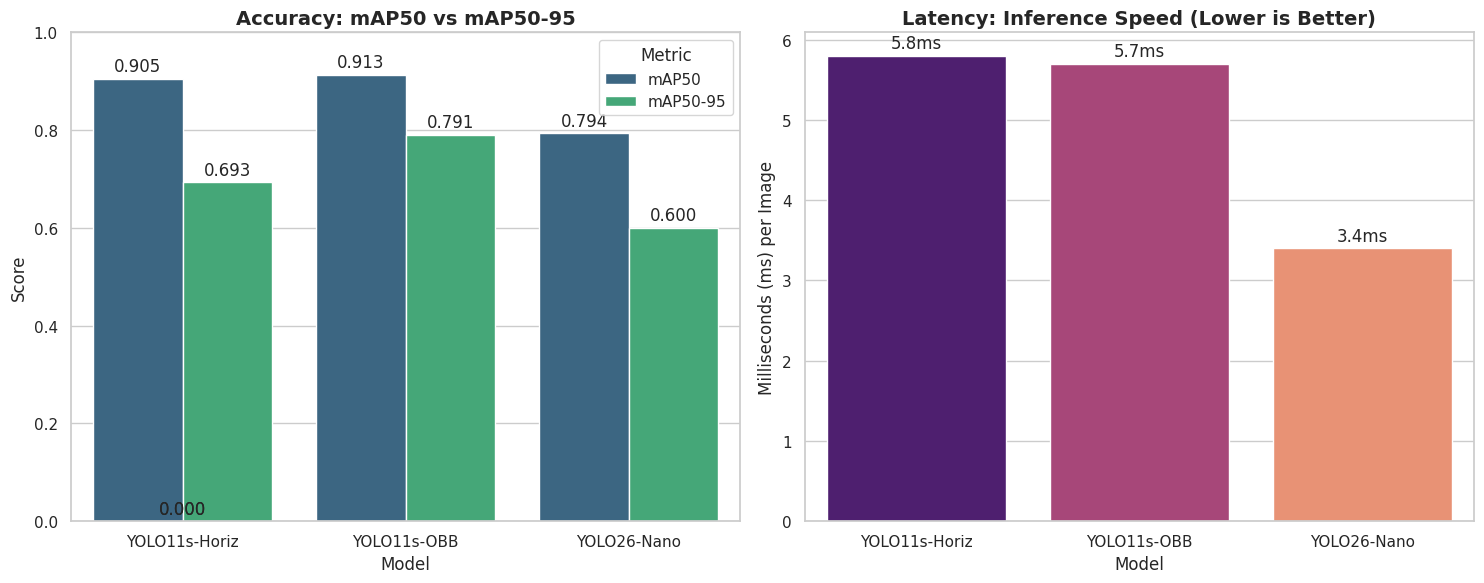


🏆 FINAL AIRCRAFT DETECTION LEADERBOARD
------------------------------------------------------------
| Model         |   mAP50 |   mAP50-95 |   Speed (ms) |
|:--------------|--------:|-----------:|-------------:|
| YOLO11s-Horiz |   0.905 |      0.693 |          5.8 |
| YOLO11s-OBB   |   0.913 |      0.791 |          5.7 |
| YOLO26-Nano   |   0.794 |      0.6   |          3.4 |


In [ ]:
# Cell 7: Final Leaderboard - Accuracy & Speed Visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Aggregating your specific results
results_data = [
    {"Model": "YOLO11s-Horiz", "mAP50": 0.905, "mAP50-95": 0.693, "Speed (ms)": 5.8},
    {"Model": "YOLO11s-OBB",   "mAP50": 0.913, "mAP50-95": 0.791, "Speed (ms)": 5.7},
    {"Model": "YOLO26-Nano",   "mAP50": 0.794, "mAP50-95": 0.600, "Speed (ms)": 3.4}
]

df = pd.DataFrame(results_data)

# 2. Setup Plotting Style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Plot 1: Accuracy Comparison (mAP) ---
# We melt the dataframe to show both mAP50 and mAP50-95
df_melted = df.melt(id_vars="Model", value_vars=["mAP50", "mAP50-95"], var_name="Metric", value_name="Score")
sns.barplot(data=df_melted, x="Model", y="Score", hue="Metric", ax=axes[0], palette="viridis")
axes[0].set_title("Accuracy: mAP50 vs mAP50-95", fontsize=14, fontweight='bold')
axes[0].set_ylim(0, 1.0)
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 9), textcoords='offset points')

# --- Plot 2: Speed Comparison (Latency) ---
sns.barplot(data=df, x="Model", y="Speed (ms)", ax=axes[1], palette="magma")
axes[1].set_title("Latency: Inference Speed (Lower is Better)", fontsize=14, fontweight='bold')
axes[1].set_ylabel("Milliseconds (ms) per Image")
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f}ms', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 9), textcoords='offset points')

plt.tight_layout()
plt.show()

# 3. Print the Final Markdown Table
print("\n🏆 FINAL AIRCRAFT DETECTION LEADERBOARD")
print("-" * 60)
print(df.to_markdown(index=False))

In [ ]:
#Cell 8 : app.py
!pip install -q ultralytics torchmetrics torchvision opencv-python tqdm

import gradio as gr
from ultralytics import YOLO
import os, glob, time
from PIL import Image
from google.colab import drive

# 1. MOUNT DRIVE
drive.mount('/content/drive')

# 2. CONFIGURATION
DRIVE_BASE = "/content/drive/MyDrive/mil-plane"
WEIGHTS_DIR = os.path.join(DRIVE_BASE, "weights_backup")

# MAR20 Mapping: YOLO ID -> (A-Code, Military Name)
MAR20_MAP = {
    0: ("A1", "SU-35"), 1: ("A10", "B-1B"), 2: ("A11", "E-8"), 3: ("A12", "TU-22"),
    4: ("A13", "F-15"), 5: ("A14", "KC-135"), 6: ("A15", "F-22"), 7: ("A16", "F/A-18"),
    8: ("A17", "TU-95"), 9: ("A18", "KC-10"), 10: ("A19", "SU-34"), 11: ("A2", "C-130"),
    12: ("A20", "SU-24"), 13: ("A3", "C-17"), 14: ("A4", "C-5"), 15: ("A5", "F-16"),
    16: ("A6", "TU-160"), 17: ("A7", "E-3"), 18: ("A8", "B-52"), 19: ("A9", "P-3C")
}

MODELS_CFG = {
    "Horizontal": os.path.join(WEIGHTS_DIR, "yolo_horiz_best.pt"),
    "OBB": os.path.join(WEIGHTS_DIR, "yolo_obb_best.pt"),
    "Nano": os.path.join(WEIGHTS_DIR, "yolo26_best.pt")
}

# 3. UTILITIES
def get_drive_images():
    # Looks for any images in the mil-plane folder recursively
    files = glob.glob(os.path.join(DRIVE_BASE, "**", "*.[jJ][pP][gG]"), recursive=True) + \
            glob.glob(os.path.join(DRIVE_BASE, "**", "*.[pP][nN][gG]"), recursive=True)
    return sorted(list(set(files)))[:500]

# 4. PREDICTION LOGIC
def run_analysis(manual_img, drive_img_path, conf):
    # Determine which image to use
    img_source = manual_img if manual_img is not None else (Image.open(drive_img_path).convert("RGB") if drive_img_path else None)

    if img_source is None:
        return [None]*4 + ["### ❌ Error\nPlease upload an image or select one from the Drive Dataset tab."]

    results_plots = []
    report_sections = []

    for label, path in MODELS_CFG.items():
        if not os.path.exists(path):
            results_plots.append(None)
            report_sections.append(f"### {label}\nWeights not found at: {path}")
            continue

        model = YOLO(path)
        res = model.predict(img_source, conf=conf)[0]

        # Speed measurement
        inf_speed = res.speed.get('inference', 0)

        results_plots.append(res.plot(conf=False))

        # Detect and format counts
        cls_list = res.boxes.cls if res.boxes is not None else (res.obb.cls if hasattr(res, 'obb') else [])
        counts = {}
        for c in cls_list:
            a_code, name = MAR20_MAP.get(int(c), (f"ID{int(c)}", "Unknown"))
            # Format: A's then model name
            key = f"**{a_code}** ({name})"
            counts[key] = counts.get(key, 0) + 1

        rep = f"### {label}\n"
        rep += f"⏱️ **Speed:** {inf_speed:.1f}ms\n"
        if not counts:
            rep += "No targets identified."
        else:
            items = [f"- {k}: {v}" for k, v in counts.items()]
            rep += "\n".join(items)
        report_sections.append(rep)

    final_report = "## 📊 Intelligence Report\n\n" + "\n\n---\n\n".join(report_sections)
    return img_source, results_plots[0], results_plots[1], results_plots[2], final_report

# 5. UI LAYOUT
image_list = get_drive_images()

with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown("# 🛰️ MAR20 Intel Analysis Hub")

    with gr.Row():
        # LEFT COLUMN: INPUTS (Restructured to match image_b11f9e.png)
        with gr.Column(scale=1):
            with gr.Tabs() as input_tabs:
                with gr.Tab("Upload", id=0):
                    up_img = gr.Image(type="pil", label="Drop Image Here")
                with gr.Tab("Drive Dataset", id=1):
                    dr_img = gr.Dropdown(choices=image_list, label="Select Image Path")

            conf_slider = gr.Slider(0.1, 1.0, value=0.25, step=0.05, label="Confidence")
            run_btn = gr.Button("Analyze Models", variant="primary")

            report_out = gr.Markdown("### Results\nWaiting for analysis...")

        # RIGHT COLUMN: OUTPUTS
        with gr.Column(scale=2):
            with gr.Row():
                out_orig = gr.Image(label="Source Image")
                out_obb = gr.Image(label="YOLOv11-OBB (Rotated)")
            with gr.Row():
                out_horiz = gr.Image(label="YOLOv11-H (Horizontal)")
                out_nano = gr.Image(label="YOLO26-Nano (Fast)")

    # Event Handling
    run_btn.click(
        fn=run_analysis,
        inputs=[up_img, dr_img, conf_slider],
        outputs=[out_orig, out_horiz, out_obb, out_nano, report_out]
    )

demo.launch(share=True, debug=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipykernel_18974/2933295010.py:88: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as demo:


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://4ed48dfb75a52cabf9.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 421, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 56, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1159, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/error


0: 288x640 1 A1, 1 A19, 4 A20s, 314.6ms
Speed: 4.7ms preprocess, 314.6ms inference, 3.2ms postprocess per image at shape (1, 3, 288, 640)

0: 288x640 1 A17, 1 A19, 4 A20s, 1 A3, 1 A9, 323.1ms
Speed: 2.9ms preprocess, 323.1ms inference, 3.6ms postprocess per image at shape (1, 3, 288, 640)

0: 288x640 1 A1, 1 A19, 4 A20s, 96.4ms
Speed: 2.9ms preprocess, 96.4ms inference, 0.3ms postprocess per image at shape (1, 3, 288, 640)
